<a href="https://colab.research.google.com/github/bnsreenu/python_for_microscopists/blob/master/334_training_YOLO_V8_EM_platelets_converted_labels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


In [1]:
import torch
print(torch.cuda.is_available())

if 'model' in globals():
    del model
    
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

True


*******Predict******

In [ ]:
import os
from ultralytics import YOLO
%matplotlib inline
from matplotlib import pyplot as plt
from PIL import Image
import torch

#List the saved models in 'runs' directory. Note that you will see multiple 'train' subdirectories numbered 1, 2, 3, etc. The exact number depends on the number of epochs.
#%ls E:\University\Finalproject\BeeCount\Main\Yolo\Results\960\400+patience20_epochs_32+353\weights

#Define a project --> Destination directory for all results
project = "D:\\xxx\\xxx\\"

#Define subdirectory for this specific training
name = "xxx" 

device = 'cuda' if torch.cuda.is_available() else 'cpu'
my_new_model = YOLO('D:\\xxx\\best.pt').to(device)

new_image = "D:\\xxx" #_DSC5334.JPGd

# Prediction 
new_results = my_new_model.predict(new_image, project=project, save=True, name=name, imgsz=640, conf=0.6, show_labels=False, max_det=1000)  #Adjust conf threshold #show_labels=False 




image 1/1 E:\EUGLENA\Pictures\Main_jpg\P-JPG\P-1-2.jpg: 640x640 42 Black dots, 14.6ms
Speed: 3.4ms preprocess, 14.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to E:\EUGLENA\segment\v.1-640-3


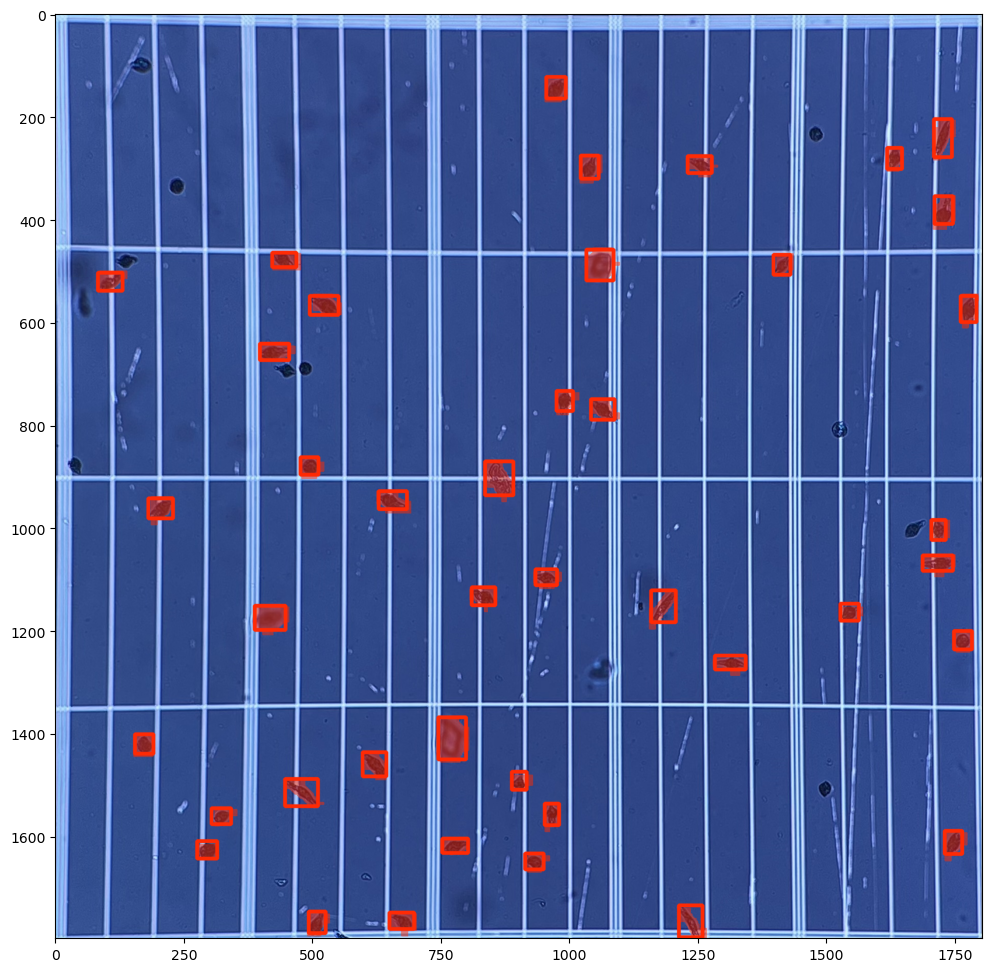

In [10]:
new_result_array = new_results[0].plot(labels=False, conf=False)
plt.figure(figsize=(12, 12)) 
plt.imshow(new_result_array)


-----

Predict image on folder

In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
from skimage.measure import regionprops
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
# 1. Folder path Picture
folder_path = r"D:\\Your picture path "  

model_path = r"D:\\Your dataset path "
# Folder for result
output_base_dir = r"D:\\Your save path"
# sup folder create eg D:\Your save path\PUV
output_folder = os.path.join(output_base_dir, os.path.basename(folder_path))
os.makedirs(output_folder, exist_ok=True)
# mm/px factor from calibrate_scale,py
MILLIMETERS_PER_PIXEL = 0.000563508
print(f"Starting analysis for folder: {folder_path} ...")
print(f"Outputs will be saved to: {output_folder}\n")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
my_new_model = YOLO(model_path).to(device)
# 2. Predict all pics in folder
results_generator = my_new_model.predict(
    source=folder_path, 
    imgsz=640, 
    conf=0.6, 
    show_labels=False, 
    max_det=1000,
    stream=True  
)
# >>> Create List For collect the data all image <<<
all_objects_list = []
summary_list = []
# 3. loop for separate image
for new_result in results_generator:
    img_path = new_result.path 
    img_name = os.path.basename(img_path) 
    img_base_name = os.path.splitext(img_name)[0] 
    
    orig_h, orig_w = new_result.orig_shape[:2]
    
    if new_result.masks is None:
        print(f"No objects detected in {img_name}")
        continue
    extracted_masks = new_result.masks.data
    detected_boxes = new_result.boxes.data
    
    if detected_boxes is not None and len(detected_boxes) > 0:
        class_labels = detected_boxes[:, -1].int().tolist()
        conf_scores = detected_boxes[:, -2].float().tolist()
    else:
        class_labels = []
        conf_scores = []
    
    props_list = []
    
    # Preapare Plot 
    new_result_array = new_result.plot(labels=False)
    plt.figure(figsize=(12, 12))
    plt.imshow(new_result_array)
    if len(class_labels) == len(extracted_masks):
        for i, (mask, class_id, conf) in enumerate(zip(extracted_masks, class_labels, conf_scores)):
            class_name = new_result.names[class_id]
            
            # Convert to numpy and resize
            mask_np = mask.cpu().numpy().astype('uint8')
            mask_resized = cv2.resize(mask_np, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
            
            props = regionprops(mask_resized)
            for prop in props:
                area_px = prop.area
                axis_length_px = prop.major_axis_length
                axis_width_px = prop.minor_axis_length
           
                final_width_mm = axis_width_px * MILLIMETERS_PER_PIXEL
                final_length_mm = axis_length_px * MILLIMETERS_PER_PIXEL
                area_mm2 = area_px * (MILLIMETERS_PER_PIXEL ** 2)
                obj_id = i + 1
                
                # Collect data List for each image
                obj_data = {
                    'Image Name': img_base_name, # เพิ่มชื่อรูปเข้าไปด้วยเพื่อให้รู้ว่ามาจากรูปไหน
                    'Object ID': obj_id,
                    'Class Name': class_name,
                    'Confidence': round(conf, 4),
                    'Width (mm)': final_width_mm,
                    'Length (mm)': final_length_mm,
                    'Area (mm^2)': area_mm2,
                    'Width (px)': axis_width_px,
                    'Length (px)': axis_length_px,
                    'Area (px^2)': area_px,
                }
                props_list.append(obj_data)
                
                # deaw Object ID on image
                y0, x0, y1, x1 = prop.bbox
                center_x = (x0 + x1) / 2
                center_y = (y0 + y1) / 2
                plt.text(center_x, center_y, str(obj_id), color='white', fontsize=12, fontweight='bold', ha='center', va='center')
    else:
        print(f"Mismatch between masks and class labels count in {img_name}.")
    # 4. Manage each image
    if len(props_list) > 0:
        props_df = pd.DataFrame(props_list)
        numeric_cols = ['Confidence', 'Width (mm)', 'Length (mm)', 'Area (mm^2)', 'Width (px)', 'Length (px)', 'Area (px^2)']
        
        # ---  Summary each image ---
        mean_vals = {col: props_df[col].mean() for col in numeric_cols}
        std_vals = {col: props_df[col].std() for col in numeric_cols}
        
        summary_row = {'Image Name': img_base_name, 'Total Objects': len(props_list)}
        for col in numeric_cols:
            summary_row[f'Mean {col}'] = mean_vals[col]
            summary_row[f'STDEV {col}'] = std_vals[col]
        summary_list.append(summary_row)
        
        
        all_objects_list.extend(props_list)
        # --- Save CSV each image  ---
        mean_row_indv = mean_vals.copy()
        mean_row_indv['Image Name'] = img_base_name
        mean_row_indv['Object ID'] = 'MEAN'
        mean_row_indv['Class Name'] = ''
        
        stdev_row_indv = std_vals.copy()
        stdev_row_indv['Image Name'] = img_base_name
        stdev_row_indv['Object ID'] = 'STDEV'
        stdev_row_indv['Class Name'] = ''
        
        props_df_indv = pd.concat([props_df, pd.DataFrame([mean_row_indv, stdev_row_indv])], ignore_index=True)
        csv_path = os.path.join(output_folder, f"{img_base_name}.csv")
        props_df_indv.to_csv(csv_path, index=False)
        
        # --- Save file ID  ---
        plt.title(f"Detected Cells: {img_name}", fontsize=16)
        plt.axis('off')
        img_output_path = os.path.join(output_folder, f"{img_base_name}_Predict.jpg")
        plt.savefig(img_output_path, dpi=300, bbox_inches='tight')
        
        print(f"Saved: {img_base_name}.csv and {img_base_name}_Predict.jpg ({len(props_list)} objects)")
        
    plt.close()
# 5. (All Objects Combined และ Summary)
folder_name_for_file = os.path.basename(folder_path)
if len(all_objects_list) > 0:
    # 5.1 All Objects Combined
    all_objects_df = pd.DataFrame(all_objects_list)
    numeric_cols = ['Confidence', 'Width (mm)', 'Length (mm)', 'Area (mm^2)', 'Width (px)', 'Length (px)', 'Area (px^2)']
    
    # Mean, STDEV, Object 
    global_mean = {col: all_objects_df[col].mean() for col in numeric_cols}
    global_mean['Image Name'] = 'ALL IMAGES COMBINED'
    global_mean['Object ID'] = 'MEAN'
    global_mean['Class Name'] = ''
    
    global_std = {col: all_objects_df[col].std() for col in numeric_cols}
    global_std['Image Name'] = 'ALL IMAGES COMBINED'
    global_std['Object ID'] = 'STDEV'
    global_std['Class Name'] = ''
    
    all_objects_df = pd.concat([all_objects_df, pd.DataFrame([global_mean, global_std])], ignore_index=True)
    all_objects_csv_path = os.path.join(output_folder, f"00_All_Objects_Combined_{folder_name_for_file}.csv")
    all_objects_df.to_csv(all_objects_csv_path, index=False)
    print(f"\n[+] Saved All Objects Combined to: {all_objects_csv_path}")
if len(summary_list) > 0:
    # 5.2 Summary each image
    summary_df = pd.DataFrame(summary_list)
    summary_csv_path = os.path.join(output_folder, f"00_Summary_Mean_STDEV_{folder_name_for_file}.csv")
    summary_df.to_csv(summary_csv_path, index=False)
    print(f"[+] Saved Summary Mean/STDEV to: {summary_csv_path}")
print("=" * 50)
print(f"All images in '{folder_name_for_file}' processed successfully!")
print(f"Check your outputs in: {output_folder}")